# DARLIN lineage tracing

Two analyses from the [CoSpar tutorial](https://cospar.readthedocs.io/en/latest/20231122_DARLIN_in_vivo_hematopoiesis.html): clone output and clonal coupling. The data contain one collection time. The tutorial's `t0/t1` labels group cell types for analysis.

Run the cells in order. The first run downloads about 333 MB unless `DARLIN_DATA` points to an existing file.

In [1]:
from __future__ import annotations

import hashlib
import importlib.metadata
import json
import time
from pathlib import Path

import anndata as ad
import cospar as cs
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import scipy.sparse as sp
from statsmodels.stats.multitest import multipletests

DATA_NAME = "tissue_adata_refined_20221106_joint.h5ad"
DATA_URL = ("https://westlakeu-my.sharepoint.com/:u:/g/personal/"
            "wangshouwen_westlake_edu_cn/ETiN1opaD-lFsmUOelCqXcEBU3tGJNNtdnYCREtMDqUqfA"
            "?e=BzHhr3&download=1")
TUTORIAL = "https://cospar.readthedocs.io/en/latest/20231122_DARLIN_in_vivo_hematopoiesis.html"
FATES = ["HSC", "LMPP", "MkP", "Ery", "Mon", "Neu"]
SEED = 20261005

def sha256(path: Path) -> str:
    h = hashlib.sha256()
    with path.open("rb") as f:
        for block in iter(lambda: f.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()

def fetch_data(path: Path) -> Path:

    path = Path(path)
    if path.exists():
        with path.open("rb") as f:
            if f.read(8) != b"\x89HDF\r\n\x1a\n":
                raise ValueError(f"Not an HDF5 file: {path}")
        return path
    path.parent.mkdir(parents=True, exist_ok=True)
    part = path.with_suffix(".part")
    try:
        with requests.get(DATA_URL, stream=True, timeout=(20, 90)) as r:
            r.raise_for_status()
            with part.open("wb") as f:
                for block in r.iter_content(1024 * 1024):
                    if block:
                        f.write(block)
            expected = r.headers.get("Content-Length")
            if expected and part.stat().st_size != int(expected):
                raise ValueError("Incomplete download")
        with part.open("rb") as f:
            if f.read(8) != b"\x89HDF\r\n\x1a\n":
                raise ValueError("Download is not HDF5 (possibly an expired sharing link)")
        part.replace(path)
        path.with_suffix(".provenance.json").write_text(json.dumps({
            "source_url": DATA_URL, "retrieved_at_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
            "bytes": path.stat().st_size, "sha256": sha256(path),
        }, indent=2))
    finally:
        part.unlink(missing_ok=True)
    return path

In [2]:
def prepare_data(path: Path):

    src = ad.read_h5ad(path, backed="r")
    try:
        mask = (src.obs["tissue"] == "Skull") & (src.obs["state_info"] != "Dc")
        obs = src.obs.loc[mask].copy()
        xclone = sp.csr_matrix(src.obsm["X_clone"][mask.to_numpy()])
        original_shape = [int(src.n_obs), int(src.n_vars)]
        n_genes = int(src.n_vars)
    finally:
        src.file.close()
    time_map = {"HSC": "t0", "LMPP": "t0", "MkP": "t1", "Ery": "t1",
                "Mon": "t1", "Neu": "t1", "Baso": "t1"}

    original_labels = obs["cell_type"].astype(str)
    in_scope = original_labels.isin(time_map)
    obs["state_info"] = pd.Categorical(original_labels.where(in_scope, "Unassigned"))
    obs["time_info"] = pd.Categorical(original_labels.map(time_map).fillna("unassigned"))
    assert xclone.shape[0] == len(obs)
    assert np.all(xclone.data >= 0) and np.all(np.isfinite(xclone.data))

    a = ad.AnnData(X=sp.csr_matrix((len(obs), 0)), obs=obs)
    a.obsm["X_clone"] = xclone
    a.uns["data_des"] = ["Skull"]
    a.uns["clone_id"] = np.arange(xclone.shape[1])
    size = np.asarray(xclone.sum(axis=0)).ravel()
    summary = {
        "original_shape": original_shape, "skull_cells": len(obs), "original_gene_count": n_genes,
        "all_nonempty_clones": int((size > 0).sum()),
        "cell_type_counts": {str(k): int(v) for k, v in obs["cell_type"].value_counts(dropna=False).items()},
        "cells_with_barcode_before_filter": int((np.asarray(xclone.sum(axis=1)).ravel() > 0).sum()),
        "one_observed_time_point": True, "t0_t1_are_cell_type_labels": True,
        "unassigned_or_out_of_scope_cells": int((~in_scope).sum()),
    }
    cs.settings.verbosity = 0
    cs.tl.filter_clones(a, clone_size_threshold=2, filter_larger_clones=False)
    assert a.obsm["X_clone"].shape[1] == int((size >= 2).sum())
    summary["clones_at_least_two_cells"] = a.obsm["X_clone"].shape[1]
    return a, summary

def clone_output(a, out: Path) -> dict:

    out = Path(out); out.mkdir(parents=True, exist_ok=True)
    coarse, names = cs.tl.coarse_grain_clone_over_cell_clusters(a, selected_fates=FATES, normalize=True)
    names = list(names)
    hsc = coarse[names.index("HSC")] > 0
    lmpp_only = (coarse[names.index("LMPP")] > 0) & ~hsc
    pieces = []
    for select in [hsc, lmpp_only]:

        sub = cs.tl.generate_adata_from_X_clone(sp.csr_matrix(coarse[:, select]), state_info=names)
        matrix, sub_names = cs.tl.coarse_grain_clone_over_cell_clusters(sub, selected_fates=names, normalize=True)
        assert list(sub_names) == names
        assert np.allclose(matrix.sum(axis=0), 1, atol=1e-6)
        ordered = cs.pl.custom_hierachical_ordering(np.arange(len(names)), matrix)
        pieces.append(ordered)
    matrix = np.hstack(pieces).T
    pd.DataFrame(matrix, columns=names).to_csv(out / "figure1_heatmap_values.csv", index_label="display_row")
    raw, raw_names = cs.tl.coarse_grain_clone_over_cell_clusters(a, selected_fates=FATES, normalize=False)
    assert list(raw_names) == names
    pd.DataFrame(raw.T, columns=names, index=a.uns["clone_id"]).to_csv(out / "clone_counts.csv", index_label="original_clone_column")
    selected = hsc | lmpp_only
    mature = [names.index(x) for x in ["MkP", "Ery", "Mon", "Neu"]]
    observed = raw[mature][:, selected]
    n_mature_fates = (observed > 0).sum(axis=0)

    outcomes = matrix[:, mature]
    outcomes = outcomes[outcomes.sum(axis=1) > 0]
    fractions = outcomes / (outcomes.sum(axis=1, keepdims=True) + 1e-10)
    fig, ax = plt.subplots(figsize=(6.2, 7.2))
    im = ax.imshow(matrix, aspect="auto", interpolation="nearest", cmap="Reds", vmin=0, vmax=1)
    ax.set_xticks(range(len(names)), names)
    ax.set_xlabel("Observed cell type")
    ax.set_ylabel("Clone (ordered within HSC-containing / LMPP-only groups)")
    ax.set_title(f"Observed output of {len(matrix)} HSPC-associated clones\nClones with at least two sampled cells")
    if hsc.sum() and lmpp_only.sum():
        ax.axhline(hsc.sum() - 0.5, color="black", linewidth=0.8)
    fig.colorbar(im, ax=ax, label="Normalized clone contribution")
    fig.tight_layout(); fig.savefig(out / "figure1_clone_output.png", dpi=180); plt.close(fig)
    return {
        "hspc_associated_clones": int(selected.sum()), "hsc_containing_clones": int(hsc.sum()),
        "lmpp_without_hsc_clones": int(lmpp_only.sum()),
        "hspc_clones_with_selected_mature_output": int((n_mature_fates > 0).sum()),
        "strict_single_selected_mature_fate_clones": int((n_mature_fates == 1).sum()),
        "tutorial_gt_099_fraction": float((fractions > .99).sum(axis=1).mean()),
        "omitted_fate": "Baso (as in the selected-fates tutorial panels)",
    }

In [3]:
def coupling(a, out: Path, simulations: int = 10000, seed: int = SEED) -> dict:

    out = Path(out); out.mkdir(parents=True, exist_ok=True)
    np.random.seed(seed)
    b, null = cs.tl.pvalue_for_fate_coupling(a, selected_fates=FATES,
                                         max_N_simutation=simulations, normalize=True)
    info = b.uns["fate_coupling_X_clone"]
    c = info["X_coupling"]; names = list(info["fate_names"])
    assert np.allclose(c, c.T) and np.allclose(np.diag(c), 1)
    assert np.isfinite(null).all() and ((c >= -1e-9) & (c <= 1 + 1e-9)).all()
    z, _ = cs.tl.coarse_grain_clone_over_cell_clusters(b, selected_fates=names, normalize=True)
    gram = z @ z.T
    cosine = gram / np.sqrt(np.outer(np.diag(gram), np.diag(gram)))
    assert np.allclose(c, cosine), "Independent cosine calculation disagrees"

    p_plus_one = (1 + (null >= c[None, :, :]).sum(axis=0)) / (simulations + 1)
    upper = np.triu_indices(len(names), k=1)
    q = np.full(c.shape, np.nan)
    q[upper] = multipletests(p_plus_one[upper], method="fdr_bh")[1]
    q[(upper[1], upper[0])] = q[upper]
    for filename, values in [("coupling", c), ("tutorial_p_greater", info["pvalue_greater"]),
                              ("p_greater_plus_one", p_plus_one), ("q_bh", q)]:
        pd.DataFrame(values, index=names, columns=names).to_csv(out / f"{filename}.csv")
    np.savez_compressed(out / "coupling_null.npz", null=null, observed=c, names=np.array(names), seed=seed)
    rows = [{"fate_a": names[i], "fate_b": names[j], "coupling": float(c[i, j]),
             "tutorial_p_greater": float(info["pvalue_greater"][i, j]),
             "p_greater_plus_one": float(p_plus_one[i, j]), "q_bh": float(q[i, j])}
            for i, j in zip(*upper)]
    pd.DataFrame(rows).sort_values("q_bh").to_csv(out / "coupling_pairs.csv", index=False)
    order = [names.index(x) for x in ["MkP", "HSC", "Ery", "Neu", "Mon", "LMPP"]]
    plot_c = c[np.ix_(order, order)]; plot_q = q[np.ix_(order, order)]
    fig, ax = plt.subplots(figsize=(6.8, 6.1))
    im = ax.imshow(plot_c, cmap="Reds", vmin=0, vmax=.5)
    labels = [names[i] for i in order]
    ax.set_xticks(range(len(labels)), labels); ax.set_yticks(range(len(labels)), labels)
    for i in range(len(labels)):
        for j in range(len(labels)):
            star = "*" if i != j and plot_q[i, j] < .05 else ""
            ax.text(j, i, f"{plot_c[i,j]:.2f}{star}", ha="center", va="center",
                    color="white" if plot_c[i, j] > .28 else "black", fontsize=10)
    ax.set_title("Clonal coupling between observed cell types\nCoSpar SW normalized overlap")
    fig.colorbar(im, ax=ax, label="Coupling (color saturates at 0.5)")
    fig.text(.5, .015, f"* BH q < 0.05; {simulations:,} permutations within artificial t0/t1 groups", ha="center", fontsize=9)
    fig.tight_layout(rect=(0, .04, 1, 1)); fig.savefig(out / "figure2_clonal_coupling.png", dpi=180); plt.close(fig)
    return {"simulations": simulations, "seed": seed, "unique_pairs_tested": len(rows),
            "pairs_q_lt_005": [r for r in rows if r["q_bh"] < .05],
            "coupling_input_cells": int(b.n_obs), "independent_cosine_check": True}

def run(data: Path, out: Path, simulations=10000):
    started = time.monotonic(); out = Path(out); out.mkdir(parents=True, exist_ok=True)
    data = fetch_data(Path(data))
    a, summary = prepare_data(data)
    summary.update(clone_output(a, out))
    print(json.dumps(summary, indent=2), flush=True)
    summary["coupling_analysis"] = coupling(a, out, simulations)
    summary["input"] = {"filename": data.name, "bytes": data.stat().st_size, "sha256": sha256(data), "source_url": DATA_URL}
    summary["versions"] = {p: importlib.metadata.version(p) for p in ["cospar", "scanpy", "anndata", "numpy", "scipy", "pandas"]}
    summary["runtime_seconds"] = round(time.monotonic() - started, 2)
    summary["tutorial"] = TUTORIAL
    (out / "summary.json").write_text(json.dumps(summary, indent=2))
    print(json.dumps(summary, indent=2), flush=True)
    return summary

In [4]:
import os
from IPython.display import Image, display
from IPython.utils.capture import capture_output

DATA = Path(os.environ.get("DARLIN_DATA", "data/" + DATA_NAME))
OUT = Path("results/task1")
with capture_output() as run_log:
    summary = run(DATA, OUT, simulations=10000)
keys = ["skull_cells", "clones_at_least_two_cells", "hspc_associated_clones",
        "hspc_clones_with_selected_mature_output", "strict_single_selected_mature_fate_clones"]
display(pd.Series({key: summary[key] for key in keys}, name="count").to_frame())

,count
skull_cells,6094
clones_at_least_two_cells,393
hspc_associated_clones,187
hspc_clones_with_selected_mature_output,140
strict_single_selected_mature_fate_clones,68


## Clone output

Rows represent clones and columns represent observed cell types. The upper block contains HSC; the lower block contains LMPP without HSC. Color shows normalized contribution, following both normalization steps in the tutorial.

Of 187 HSPC-associated clones, 140 have selected downstream output. Among those, 68 (48.6%) have one observed outcome. Missing descendants and excluded tissues or fates can make a clone appear restricted, so this does not establish intrinsic unipotency.

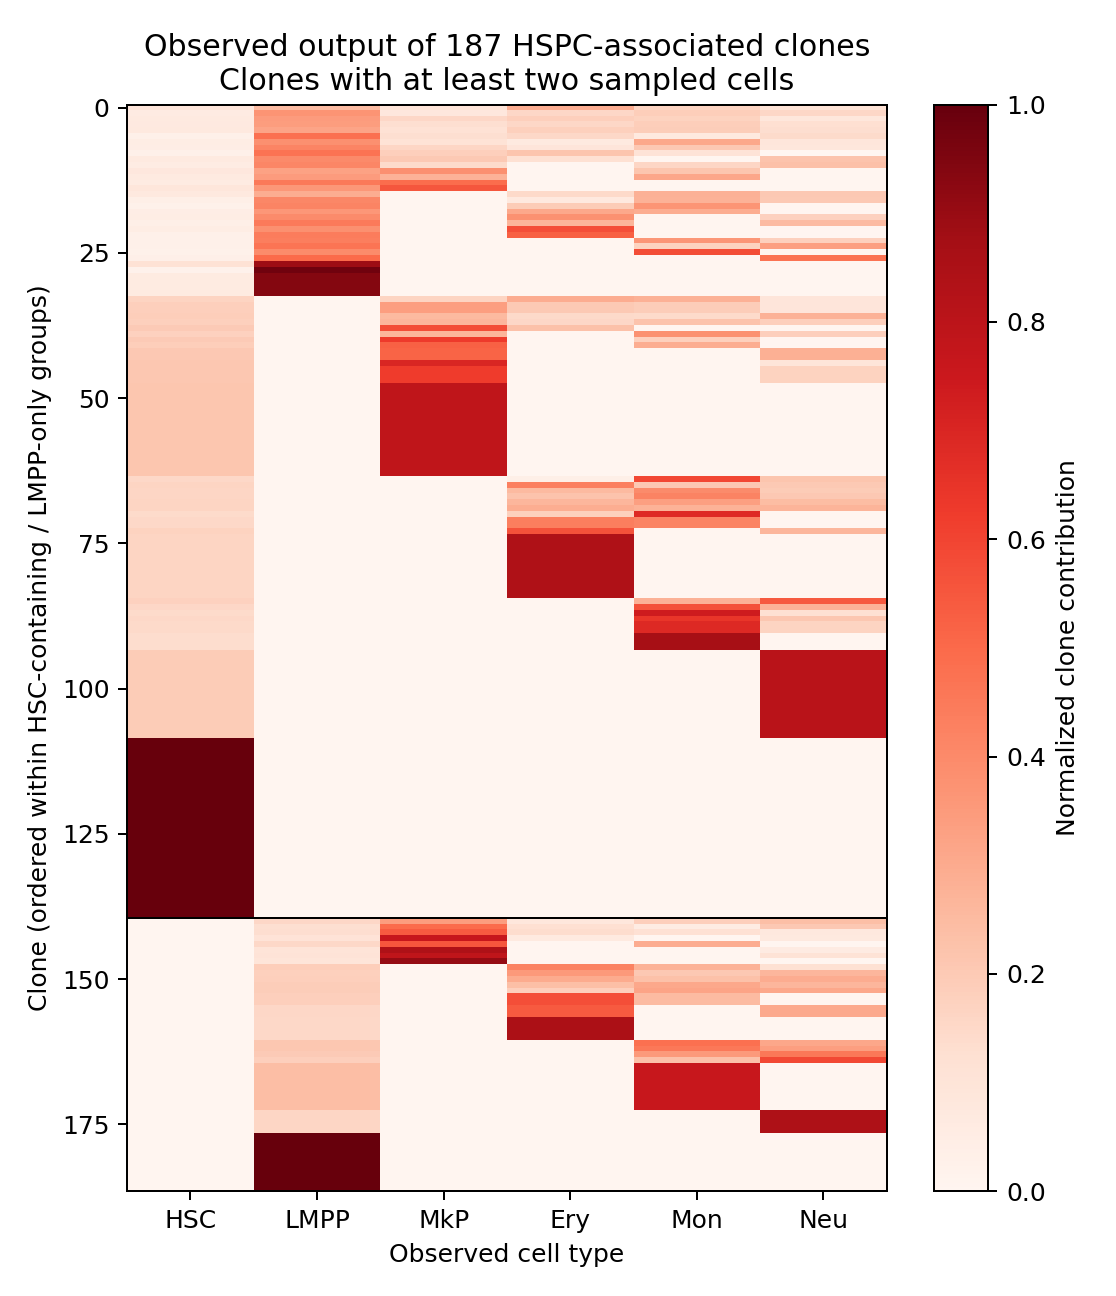

Single observed outcome: 48.57%


In [5]:
display(Image(filename=str(OUT / "figure1_clone_output.png")))
counts = pd.read_csv(OUT / "clone_counts.csv", index_col=0)
selected = (counts.HSC > 0) | (counts.LMPP > 0)
outcomes = (counts.loc[selected, ["MkP", "Ery", "Mon", "Neu"]] > 0).sum(axis=1)
assert (outcomes > 0).sum() == 140
assert (outcomes == 1).sum() == 68
print(f"Single observed outcome: {(outcomes == 1).sum() / (outcomes > 0).sum():.2%}")

## Clonal coupling

Coupling measures cosine overlap between normalized clonal contribution vectors. The test shuffles barcode rows within the artificial time groups, using 10,000 permutations and seed 20261005.

HSC–MkP coupling is 0.381, with a plus-one p-value of about 0.00010 and BH-adjusted q of 0.00150 across 15 pairs. LMPP–Mon does not pass the correction. Plus-one p-values and BH correction are additions to the tutorial; its original p-values are also saved. Coupling indicates association and does not establish a directional transition.

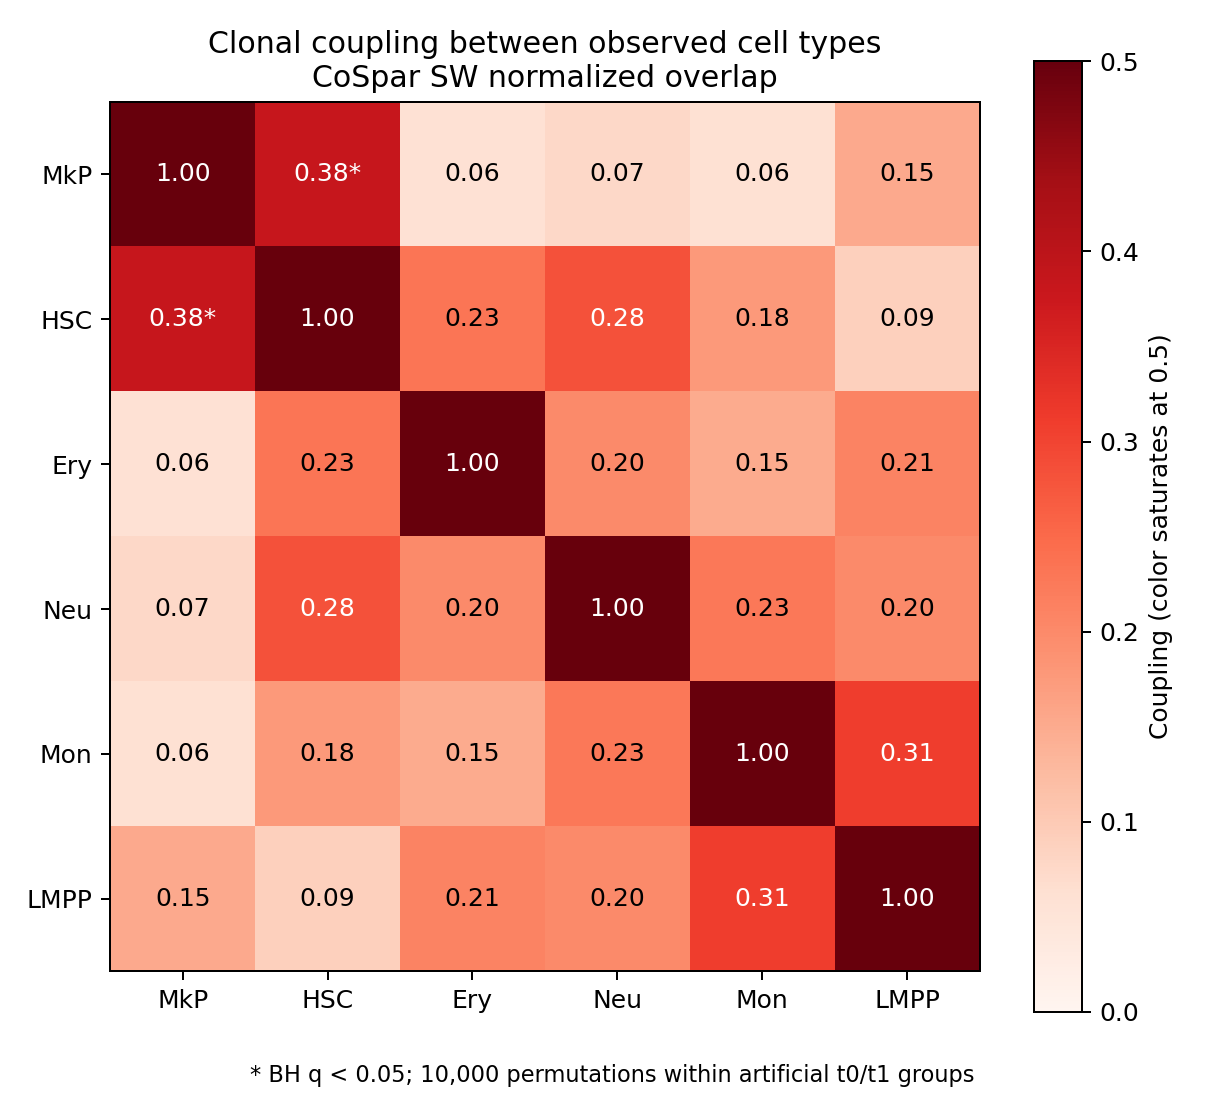

,fate_a,fate_b,coupling,tutorial_p_greater,p_greater_plus_one,q_bh
0,HSC,MkP,0.381173,0.0000,0.000100,0.001500
1,LMPP,Mon,0.308688,0.0224,0.022498,0.168733


In [6]:
display(Image(filename=str(OUT / "figure2_clonal_coupling.png")))
pairs = pd.read_csv(OUT / "coupling_pairs.csv")
display(pairs.head(2))
assert summary["coupling_analysis"]["independent_cosine_check"]
assert len(pairs) == 15